In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from scipy.stats import poisson
import scipy

In [90]:
file = r"C:\Users\Andrew\Documents\Acoustic-Space-Boiling\Data\After_May\MATLAB 2-15 PM Thu, Oct 31, 2024 Run8 .csv"
# file = r"C:\Users\Andrew\Documents\Acoustic-Space-Boiling\Data\After_May\MATLAB 4-29 PM Thu, Oct 10, 2024 Run8 .csv"
# file = r"C:\Users\Andrew\Documents\Acoustic-Space-Boiling\Data\After_May\MATLAB 1-15 PM Thu, Aug 22, 2024 Run5 .csv"
# file = r"C:\Users\Andrew\Documents\Acoustic-Space-Boiling\Data\After_May\MATLAB 12-54 PM Fri, Jun 28, 2024 Run7 .csv"
# file = r"C:\Users\Andrew\Documents\Acoustic-Space-Boiling\Data\After_May\MATLAB 12-47 PM Thu, Nov 7, 2024 Run6 .csv"


data = pd.read_csv(file, index_col="Time")
time = data.index

acceleration0 = data['0'] #Using only accelerometer 0

def clamp(value, lower=0.015, upper=0.1):
    return max(lower, min(value, upper))

def get_peaks(acceleration0):
    """
    acceleration0: accelerometer data, measured to the 10,000th of a second
    Returns: x and y coordinates of peaks
    """
    percentile = np.percentile(acceleration0, 99.5)
    percent_of_max = 0.1*np.max(acceleration0)

    height = clamp(max(percentile, percent_of_max))
    distance = 350 + 5 / height

    x, y = scipy.signal.find_peaks(acceleration0, distance=distance, height=height)
    x = x / 10000
    y = y["peak_heights"]  # unpack data
    return x, y

def get_best_gmm_by_bic_jump(peak_amplitudes, n_components_range=range(1, 4), threshold=-50):
    """
    Fits Gaussian Mixture Models (GMM) for different numbers of components and selects the best model 
    based on the largest negative jump in BIC (Bayesian Information Criterion), provided the jump is ≤ threshold.
    
    Parameters:
        peak_amplitudes (numpy array): The data to fit the GMM on.
        n_components_range (range): The range of components to evaluate.
        threshold (float): The minimum BIC decrease required to consider the jump optimal.
    
    Returns:
        best_gmm (GaussianMixture): The best-fitting GMM model.
        best_n_components (int): The optimal number of components.
        bic_list (list): List of computed BIC values.
    """
    best_gmm = None
    best_n_components = 1
    bic_list = []
    gmm_list = []

    # Fit models and store BIC values
    for n_components in n_components_range:
        gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
        gmm.fit(peak_amplitudes)
        bic = gmm.bic(peak_amplitudes)
        bic_list.append(round(float(bic), 2))
        gmm_list.append(gmm)

    # Compute BIC differences
    bic_diffs = np.diff(bic_list)

    # Determine the best model based on the largest negative jump in BIC (≤ threshold)
    if len(bic_diffs) > 0:
        greatest_decrease_index = np.argmin(bic_diffs)  # Find the largest negative jump
        if bic_diffs[greatest_decrease_index] <= threshold:
            best_n_components = greatest_decrease_index + 2  # Adjust index to component count
            best_gmm = gmm_list[greatest_decrease_index + 1]
        else:
            best_gmm = gmm_list[0]  # Default to 1 component if no significant decrease found

    return best_gmm, best_n_components, bic_list


BIC values: [-234.41, -415.13, -409.57]
Best number of components: 2


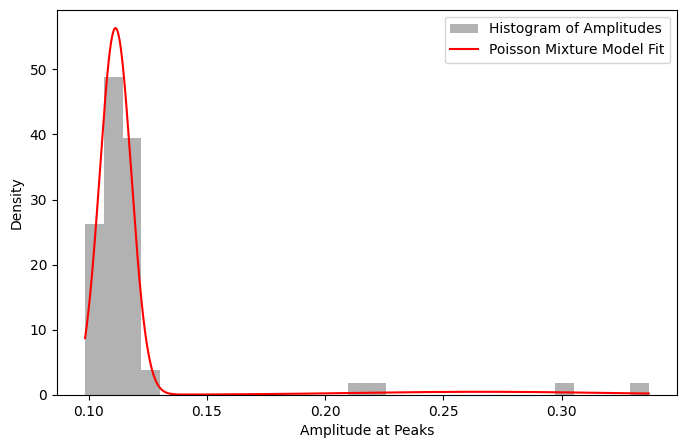

In [91]:
peaks, _ = get_peaks(acceleration0)
peak_amplitudes = acceleration0.loc[peaks].values.reshape(-1, 1)

best_gmm, best_n_components, bic_list = get_best_gmm_by_bic_jump(peak_amplitudes)

print(f"BIC values: {bic_list}")
print(f"Best number of components: {best_n_components}")

x = np.linspace(min(peak_amplitudes), max(peak_amplitudes), 1000).reshape(-1, 1)
log_prob = best_gmm.score_samples(x)
responsibilities = np.exp(log_prob)

plt.figure(figsize=(8, 5))
plt.hist(peak_amplitudes, bins=30, density=True, alpha=0.6, color='gray', label="Histogram of Amplitudes")
plt.plot(x, responsibilities, label="Poisson Mixture Model Fit", color='red')
plt.xlabel("Amplitude at Peaks")
plt.ylabel("Density")
plt.legend()
plt.show()


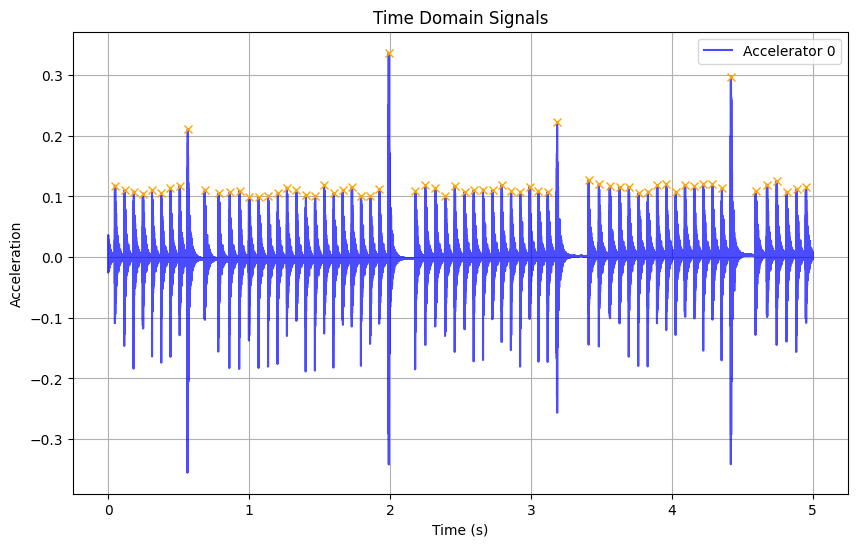

In [92]:
plt.figure(figsize=(10, 6))
plt.plot(time, acceleration0, label='Accelerator 0', color='blue', alpha=0.7)
plt.plot(peaks, acceleration0.loc[peaks], "x", color="orange")
plt.title('Time Domain Signals')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration')
plt.legend()
plt.grid(True)
plt.show()

[[0.0685]
 [0.066 ]
 [0.0664]
 [0.0627]
 [0.0655]
 [0.0653]
 [0.0651]
 [0.0576]
 [0.1217]
 [0.097 ]
 [0.0786]
 [0.07  ]
 [0.0688]
 [0.0662]
 [0.0676]
 [0.0693]
 [0.0645]
 [0.0665]
 [0.0684]
 [0.0659]
 [0.0634]
 [0.0677]
 [0.0659]
 [0.0623]
 [0.0651]
 [0.0671]
 [0.0625]
 [0.0676]
 [0.1898]
 [0.0702]
 [0.0702]
 [0.0724]
 [0.0656]
 [0.0704]
 [0.0641]
 [0.0666]
 [0.069 ]
 [0.063 ]
 [0.0679]
 [0.0654]
 [0.0659]
 [0.0623]
 [0.065 ]
 [0.0676]
 [0.2231]
 [0.0728]
 [0.0796]
 [0.0676]
 [0.0648]
 [0.0697]
 [0.0668]
 [0.0669]
 [0.063 ]
 [0.0682]
 [0.0634]
 [0.0684]
 [0.0624]
 [0.0651]
 [0.0672]
 [0.0648]
 [0.1764]
 [0.0781]
 [0.0692]
 [0.0724]
 [0.069 ]
 [0.0685]]
BIC values: [-275.14, -470.82, -466.59]
Best number of components: 2
Component 0:
[0.0685 0.066  0.0664 0.0627 0.0655 0.0653 0.0651 0.0576 0.07   0.0688
 0.0662 0.0676 0.0693 0.0645 0.0665 0.0684 0.0659 0.0634 0.0677 0.0659
 0.0623 0.0651 0.0671 0.0625 0.0676 0.0702 0.0702 0.0724 0.0656 0.0704
 0.0641 0.0666 0.069  0.063  0.0679 0.0654 0

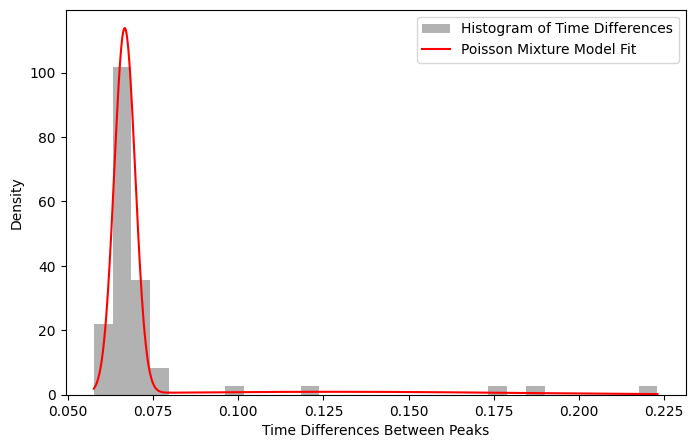

In [93]:
peaks, _ = get_peaks(acceleration0)

time_differences = np.diff(peaks).reshape(-1, 1) 

print(time_differences)

best_gmm, best_n_components, bic_list = get_best_gmm_by_bic_jump(time_differences, n_components_range=range(1, 4))

print(f"BIC values: {bic_list}")
print(f"Best number of components: {best_n_components}")

probabilities = best_gmm.predict_proba(time_differences)
assigned_components = np.argmax(probabilities, axis=1)

time_components = pd.DataFrame({
    "Time Difference": time_differences.flatten(),
    "Component": assigned_components
})

for component in range(best_gmm.n_components):
    print(f"Component {component}:")
    print(time_components[time_components["Component"] == component]["Time Difference"].values)
    print("\n")

x = np.linspace(min(time_differences), max(time_differences), 1000).reshape(-1, 1)
log_prob = best_gmm.score_samples(x)
responsibilities = np.exp(log_prob)

plt.figure(figsize=(8, 5))
plt.hist(time_differences, bins=30, density=True, alpha=0.6, color='gray', label="Histogram of Time Differences")
plt.plot(x, responsibilities, label="Poisson Mixture Model Fit", color='red')
plt.xlabel("Time Differences Between Peaks")
plt.ylabel("Density")
plt.legend()
plt.show()


BIC values: [6984.9, 6633.73, 6550.15]
Best number of components: 2
Component 0:
[1.8756 1.9432 2.133  2.2032 2.2734 2.3458 2.4114 2.4818 2.5459 2.6125
 2.6815 2.7445 2.8124 2.8778 2.9437 3.006  3.071  3.1386 3.3617 3.4345
 3.5141 3.5817 3.6465 3.7162 3.783  3.8499 3.9129 3.9811 4.0445 4.1129
 4.1753 4.2404 4.3076 4.3724 4.5488 4.6269 4.6961 4.7685 4.8375 4.906
 1.8747 2.0645 2.1347 2.2049 2.2773 2.3429 2.4133 2.4774 2.544  2.613
 2.676  2.7439 2.8093 2.8752 2.9375 3.0025 3.0701 3.2932 3.366  3.4456
 3.5132 3.578  3.6477 3.7145 3.7814 3.8444 3.9126 3.976  4.0444 4.1068
 4.1719 4.2391 4.3039 4.4803 4.5584 4.6276 4.7    4.769  4.8375 1.9985
 2.0687 2.1389 2.2113 2.2769 2.3473 2.4114 2.478  2.547  2.61   2.6779
 2.7433 2.8092 2.8715 2.9365 3.0041 3.2272 3.3    3.3796 3.4472 3.512
 3.5817 3.6485 3.7154 3.7784 3.8466 3.91   3.9784 4.0408 4.1059 4.1731
 4.2379 4.4143 4.4924 4.5616 4.634  4.703  4.7715 1.9321 2.0023 2.0725
 2.1449 2.2105 2.2809 2.345  2.4116 2.4806 2.5436 2.6115 2.6769 2.7428

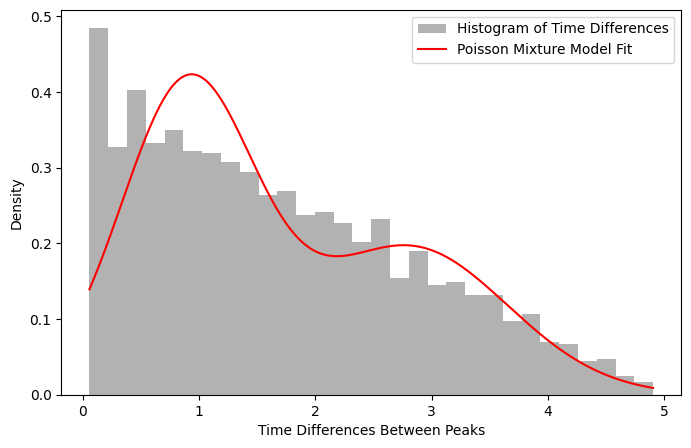

In [94]:
res = []
for i in range(len(peaks) - 1):
    for j in range(i + 1, len(peaks)):
        res.append(abs(peaks[j] - peaks[i])) 

time_differences = np.array(res).reshape(-1, 1)

best_gmm, best_n_components, bic_list = get_best_gmm_by_bic_jump(time_differences, n_components_range=range(1, 4))

print(f"BIC values: {bic_list}")
print(f"Best number of components: {best_n_components}")

probabilities = best_gmm.predict_proba(time_differences)
assigned_components = np.argmax(probabilities, axis=1)

time_components = pd.DataFrame({
    "Time Difference": time_differences.flatten(),
    "Component": assigned_components
})

for component in range(best_gmm.n_components):
    print(f"Component {component}:")
    print(time_components[time_components["Component"] == component]["Time Difference"].values)
    print("\n")

x = np.linspace(min(time_differences), max(time_differences), 1000).reshape(-1, 1)
log_prob = best_gmm.score_samples(x)
responsibilities = np.exp(log_prob)

plt.figure(figsize=(8, 5))
plt.hist(time_differences, bins=30, density=True, alpha=0.6, color='gray', label="Histogram of Time Differences")
plt.plot(x, responsibilities, label="Poisson Mixture Model Fit", color='red')
plt.xlabel("Time Differences Between Peaks")
plt.ylabel("Density")
plt.legend()
plt.show()
